In [1]:
#!pip install ipdb

Uber’s Driver team is interested in predicting which driver signups are most likely to start driving. To help
explore this question, we have provided a sample dataset of a cohort of driver signups in January 2015. 1
The data was pulled a few months after they signed up to include the result of whether they actually
completed their first trip. It also includes several pieces of background information gather about the driver
and their car.
We would like you to use this data set to help understand what factors are best at predicting whether a
signup will start to drive, and offer suggestions to operationalize those insights to help Uber.
See below for a detailed description of the dataset. Please include any code you wrote for the analysis
and delete the dataset when you have finished with the challenge. Please also call out any data related
assumptions or issues that you encounter.
1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided data for this
analysis (a few sentences/plots describing your approach will suffice). What fraction of the driver
signups took a first trip? (2 points)
2. Build a predictive model to help Uber determine whether or not a driver signup will start driving.
Discuss why you chose your approach, what alternatives you considered, and any concerns you
have. How valid is your model? Include any key indicators of model performance. (2 points)
3. Briefly discuss how Uber might leverage the insights gained from the model to generate more first
trips (again, a few ideas/sentences will suffice). (1 point)

My summary of task: 
- find/understand factors best at predicting whether a signup will start to drive (important variables), and offer suggestions to operationalize those

Clarifying questions: 
- can you elaborate more of driver signsup took a first trip? 

My initial thought: 
Since we want to know whether or not driver will start driving, i'm thinking of going towards the direction of decision trees/random forest



In [2]:
import pandas as pd
import numpy as np
import statistics
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
from math import sqrt

from sklearn.model_selection  import train_test_split
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,  GradientBoostingClassifier, AdaBoostClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, precision_recall_fscore_support, precision_score, recall_score

import ipdb
import seaborn as sns
sns.set()
#import graphviz

%matplotlib inline
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as scs
import scipy.stats as stats

import statsmodels.api as sm
from datetime import date, datetime, time
import os

os.getcwd()



'/Users/jeffreyochavillo/Desktop/Personal/Projects/Machine_Learning/Uber_TakeHome_Challenge'

In [3]:
data_path = '/Users/jeffreyochavillo/Desktop/Personal/Projects/Machine_Learning/Uber_TakeHome_Challenge/driver_signups.csv'
df = pd.read_csv(data_path)
print(df.columns)
print(df.head())

Index(['id', 'city_name', 'signup_os', 'signup_channel', 'signup_timestamp',
       'bgc_date', 'vehicle_added_date', 'vehicle_make', 'vehicle_model',
       'vehicle_year', 'first_completed_trip_timestamp'],
      dtype='object')
                                     id city_name signup_os signup_channel  \
0  082befb0-c1de-4c14-8700-94a7943a7545    Strark       NaN            R2D   
1  1ae6156f-63fc-40cf-9734-0995978c4b6e    Berton   ios web           Dost   
2  2a4a4eef-14ef-4ceb-82eb-66f1f7d0d219    Berton       NaN            R2D   
3  56fe7597-3ad8-4798-8be8-5fbc4e2d3151    Berton   ios web       Referral   
4  67370341-68a5-415f-acf2-be58832a8f9c   Wrouver     other       Referral   

            signup_timestamp                   bgc_date  \
0  2017-07-06 20:52:17+00:00                        NaN   
1  2017-07-03 17:51:07+00:00  2017-07-03 17:57:06+00:00   
2  2017-07-10 23:05:29+00:00                        NaN   
3  2017-07-27 18:37:21+00:00  2017-07-27 18:46:43+00:00   
4  20

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11986 entries, 0 to 11985
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id                              11986 non-null  object
 1   city_name                       11986 non-null  object
 2   signup_os                       6758 non-null   object
 3   signup_channel                  10817 non-null  object
 4   signup_timestamp                10855 non-null  object
 5   bgc_date                        7588 non-null   object
 6   vehicle_added_date              10791 non-null  object
 7   vehicle_make                    11378 non-null  object
 8   vehicle_model                   11986 non-null  object
 9   vehicle_year                    11986 non-null  int64 
 10  first_completed_trip_timestamp  6594 non-null   object
dtypes: int64(1), object(10)
memory usage: 1.0+ MB


<Axes: title={'center': '% of rows missing values'}, ylabel='variable'>

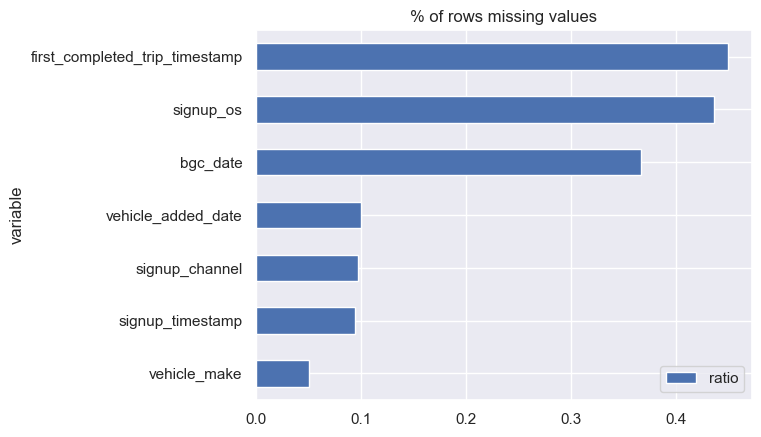

In [5]:
# dive into the data a bit
missing_df = df.isna().sum()
missing_df = pd.DataFrame({'variable' :missing_df.index,'count': missing_df.values})
missing_df['ratio'] = missing_df['count']/df.shape[0]

missing_df = missing_df[missing_df['count']>0]
missing_df.sort_values(by=['ratio'], inplace = True)
missing_df.plot(kind='barh', x = 'variable', y ='ratio', title = '% of rows missing values')

In [6]:
#include only valid signup timestamp

df = df[df["signup_timestamp"].notnull()]
df

#data cleaning

#Categorical

df.loc[df['signup_os'].isna(),'signup_os'] = 'missing'
df.loc[df['signup_channel'].isna(),'signup_channel'] = 'missing'
df.loc[df['vehicle_make'].isna(),'vehicle_make'] = 'missing'

#Datetimes

df["first_completed_trip_timestamp"] = pd.to_datetime(df['first_completed_trip_timestamp'])
df["bgc_date"] = pd.to_datetime(df['bgc_date'])
df["vehicle_added_date"] = pd.to_datetime(df['vehicle_added_date'])
df["signup_timestamp"] = pd.to_datetime(df['signup_timestamp'])

df.head(5)

,id,city_name,signup_os,signup_channel,signup_timestamp,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_trip_timestamp
0,082befb0-c1de-4c14-8700-94a7943a7545,Strark,missing,R2D,2017-07-06 20:52:17+00:00,NaT,2017-07-06 20:57:56+00:00,Volkswagen,CC,2012,NaT
1,1ae6156f-63fc-40cf-9734-0995978c4b6e,Berton,ios web,Dost,2017-07-03 17:51:07+00:00,2017-07-03 17:57:06+00:00,2017-07-03 17:56:14+00:00,Toyota,4Runner,2003,2017-07-23 00:46:50+00:00
2,2a4a4eef-14ef-4ceb-82eb-66f1f7d0d219,Berton,missing,R2D,2017-07-10 23:05:29+00:00,NaT,2017-07-11 17:59:44+00:00,Hyundai,Elantra,2015,NaT
3,56fe7597-3ad8-4798-8be8-5fbc4e2d3151,Berton,ios web,Referral,2017-07-27 18:37:21+00:00,2017-07-27 18:46:43+00:00,2017-07-27 18:46:09+00:00,Honda,Civic,2017,2017-07-31 04:27:24+00:00
4,67370341-68a5-415f-acf2-be58832a8f9c,Wrouver,other,Referral,2017-07-17 22:30:35+00:00,2017-07-17 22:36:09+00:00,2017-07-17 22:35:53+00:00,Honda,Accord,1999,NaT


In [7]:
# Data cleaning{
# train_data = train_data.drop(train_data[train_data['signup_timestamp'].isna()].index)
# train_data.loc[train_data['signup_os'].isna(), 'signup_os'] = 'Unknown'
# train_data.loc[train_data['signup_channel'].isna(), 'signup_channel'] = 'Unknown'
# train_data.loc[train_data['vehicle_make'].isna(), 'vehicle_model'] = 'Other'
# train_data['vehicle_make'] = train_data['vehicle_make'].replace(to_replace=np.NaN, value="Other")

# date_format = "%Y-%m-%dT%H:%M:%SZ"
# train_data['first_trip'] = pd.to_datetime(train_data['first_completed_trip_timestamp'],format=date_format)
# train_data['signup'] = pd.to_datetime(train_data['signup_timestamp'],format=date_format)
# train_data['signup_weekday'] = train_data['signup'].apply(lambda x: datetime.datetime.weekday(x))

# print("Time range of this cohort: {} to {}".format(
#         train_data['signup'].min(),
#         train_data['signup'].max()))

# # Data Cleaning #
# # convert type(object) to type(date)
# df["signup_timestamp"] = pd.to_datetime(df["signup_timestamp"])
# df["bgc_date"] = pd.to_datetime(df["bgc_date"])
# df["vehicle_added_date"] = pd.to_datetime(df["vehicle_added_date"])
# df["first_completed_trip_timestamp"] = pd.to_datetime(
#     df["first_completed_trip_timestamp"]
# )

# # creating "missing" for categorical variable
# df['signup_os'] = np.where(
#     df["signup_os"].notnull(),
#     df["signup_os"],
#     "missing"
# )
# df['signup_channel'] = np.where(
#     df["signup_channel"].notnull(),
#     df["signup_channel"],
#     "missing"
# )
# df['vehicle_make'] = np.where(
#     df["vehicle_make"].notnull(),
#     df["vehicle_make"],
#     "missing"
# )

# # create missing indicator for numeric varaible
# df['bgc_date_known'] = df['bgc_date'].notnull()
# df['vehicle_added_date_known'] = df['vehicle_added_date'].notnull()


In [8]:
# Defining target variable
df['conversion'] = ((df["first_completed_trip_timestamp"] - df["signup_timestamp"]).dt.days <= 30).astype(int)

# Fraction of drivers that took a first trip within 30 days of signing up
print(
    "{:.2%} of drivers took a first trip within 30 days of signing up"
    .format(df['conversion'].mean())
)

# train_data['convert'] = (
#     train_data['first_trip'] - train_data['signup']
# ) <= datetime.timedelta(days=30)
# train_data.loc[train_data['first_trip'].isna(), 'convert'] = False

# print(
#     "{:.2%} fraction of signup drivers took a first trip within 30 days of signing up."
#     .format(train_data['convert'].mean())
# )

# # create the target variable - took a first trip within 30 days of signing up
# df['signup2firsttrip_in30'] = np.where(
#     (df["first_completed_trip_timestamp"] - df["signup_timestamp"]).dt.days <= 30,
#     1,
#     0
# )

# # check how many people start first trip with in 30 days
# df['signup2firsttrip_in30'].value_counts() / df['signup2firsttrip_in30'].value_counts().sum()

# # 1 means took the first trip within 30 days since signup,
# # 0 means did not complete the first trip within 30 days since signup


55.01% of drivers took a first trip within 30 days of signing up


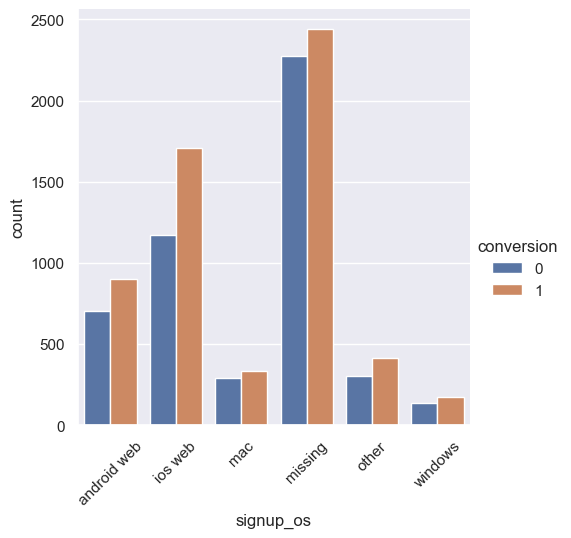

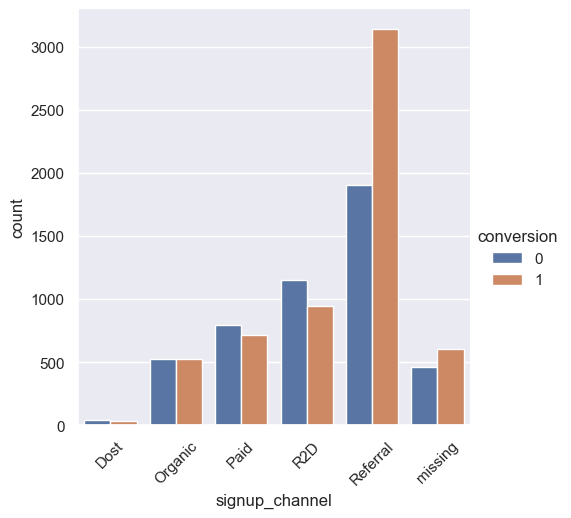

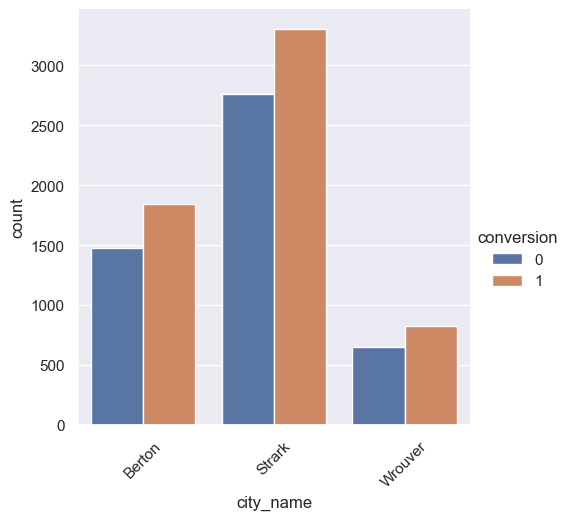

In [9]:
# Plot conversion rate comparison for given col
def plot_conversion_comparison(col):
    group_df = pd.DataFrame(
        df.groupby(['conversion', col], as_index=False).size()
    )
    group_df.reset_index(inplace=True)
    group_df.rename({'index': 'count'}, axis='columns', inplace=True)

    fig = sns.catplot(
        x=col,
        y="size",
        hue="conversion",
        data=group_df,
        kind="bar"
    )
    fig.set_xlabels(col)
    fig.set_ylabels("count")
    fig.set_xticklabels(rotation=45)

    return fig


plot_conversion_comparison('signup_os')        # ios web -> high conversion
plot_conversion_comparison('signup_channel')   # Referral -> high conversion
plot_conversion_comparison('city_name')


# res2 = df.groupby(
#     ['city_name', 'conversion', 'signup_channel'],
#     as_index=False
# ).size()

# res2 = pd.DataFrame(res2)
# res2.reset_index(inplace=True)
# res2.rename({'index': 'count'}, axis='columns', inplace=True)

# g = sns.catplot(
#     x="signup_channel",
#     y="count",
#     hue="conversion",
#     col="city_name",
#     data=res2,
#     kind="bar",
#     height=4,
#     aspect=.7
# )

# g.add_legend()
# g.set_xticklabels(rotation=90)


In [10]:
# feature engineering before model
# for date varaible

print(df.head(5))

# Date deltas in days
df["signup_to_bgc"] = (
    df["bgc_date"] - df["signup_timestamp"]
) / np.timedelta64(1, 'D')

df["signup_to_vehicle_added"] = (
    df["vehicle_added_date"] - df["signup_timestamp"]
) / np.timedelta64(1, 'D')

# Indicators
df['bgc_date_known'] = df['bgc_date'].notnull()
df['vehicle_added_date_known'] = df['vehicle_added_date'].notnull()

df.head(5)


                                     id city_name signup_os signup_channel  \
0  082befb0-c1de-4c14-8700-94a7943a7545    Strark   missing            R2D   
1  1ae6156f-63fc-40cf-9734-0995978c4b6e    Berton   ios web           Dost   
2  2a4a4eef-14ef-4ceb-82eb-66f1f7d0d219    Berton   missing            R2D   
3  56fe7597-3ad8-4798-8be8-5fbc4e2d3151    Berton   ios web       Referral   
4  67370341-68a5-415f-acf2-be58832a8f9c   Wrouver     other       Referral   

           signup_timestamp                  bgc_date  \
0 2017-07-06 20:52:17+00:00                       NaT   
1 2017-07-03 17:51:07+00:00 2017-07-03 17:57:06+00:00   
2 2017-07-10 23:05:29+00:00                       NaT   
3 2017-07-27 18:37:21+00:00 2017-07-27 18:46:43+00:00   
4 2017-07-17 22:30:35+00:00 2017-07-17 22:36:09+00:00   

         vehicle_added_date vehicle_make vehicle_model  vehicle_year  \
0 2017-07-06 20:57:56+00:00   Volkswagen            CC          2012   
1 2017-07-03 17:56:14+00:00       Toyota    

,id,city_name,signup_os,signup_channel,signup_timestamp,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_trip_timestamp,conversion,signup_to_bgc,signup_to_vehicle_added,bgc_date_known,vehicle_added_date_known
0,082befb0-c1de-4c14-8700-94a7943a7545,Strark,missing,R2D,2017-07-06 20:52:17+00:00,NaT,2017-07-06 20:57:56+00:00,Volkswagen,CC,2012,NaT,0,NaN,0.003924,False,True
1,1ae6156f-63fc-40cf-9734-0995978c4b6e,Berton,ios web,Dost,2017-07-03 17:51:07+00:00,2017-07-03 17:57:06+00:00,2017-07-03 17:56:14+00:00,Toyota,4Runner,2003,2017-07-23 00:46:50+00:00,1,0.004155,0.003553,True,True
2,2a4a4eef-14ef-4ceb-82eb-66f1f7d0d219,Berton,missing,R2D,2017-07-10 23:05:29+00:00,NaT,2017-07-11 17:59:44+00:00,Hyundai,Elantra,2015,NaT,0,NaN,0.787674,False,True
3,56fe7597-3ad8-4798-8be8-5fbc4e2d3151,Berton,ios web,Referral,2017-07-27 18:37:21+00:00,2017-07-27 18:46:43+00:00,2017-07-27 18:46:09+00:00,Honda,Civic,2017,2017-07-31 04:27:24+00:00,1,0.006505,0.006111,True,True
4,67370341-68a5-415f-acf2-be58832a8f9c,Wrouver,other,Referral,2017-07-17 22:30:35+00:00,2017-07-17 22:36:09+00:00,2017-07-17 22:35:53+00:00,Honda,Accord,1999,NaT,0,0.003866,0.003681,True,True


In [11]:
df.columns

Index(['id', 'city_name', 'signup_os', 'signup_channel', 'signup_timestamp',
       'bgc_date', 'vehicle_added_date', 'vehicle_make', 'vehicle_model',
       'vehicle_year', 'first_completed_trip_timestamp', 'conversion',
       'signup_to_bgc', 'signup_to_vehicle_added', 'bgc_date_known',
       'vehicle_added_date_known'],
      dtype='object')

In [12]:
model_cols = [
    'city_name',
    'signup_os',
    'signup_channel',
    'vehicle_make',
    'vehicle_model',
    'vehicle_year',
    'bgc_date_known',
    'vehicle_added_date_known',
    'signup_to_bgc',
    'signup_to_vehicle_added',
    'conversion'
]

df = df[model_cols]

model_df = df.copy()

import warnings
warnings.simplefilter('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score
)
from xgboost.sklearn import XGBClassifier
import xgboost as xgb

# X is our predictors, y is the label we want to predict
y = model_df['conversion']
X = model_df.drop(['conversion'], axis=1)

print("X originally..")
print(X)

cols = ['signup_to_bgc', 'signup_to_vehicle_added']
for c in cols:
    X[c] = X[c].replace(np.nan, X[c].mean())

X = pd.get_dummies(X)

print("X after dummies..")

# # One-hot encoding for categorical variables, imputing mean for numerical nans
# imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
# imputer.fit(X.values)
# X = imputer.transform(X)

print(X)


X originally..
      city_name signup_os signup_channel vehicle_make vehicle_model  \
0        Strark   missing            R2D   Volkswagen            CC   
1        Berton   ios web           Dost       Toyota       4Runner   
2        Berton   missing            R2D      Hyundai       Elantra   
3        Berton   ios web       Referral        Honda         Civic   
4       Wrouver     other       Referral        Honda        Accord   
...         ...       ...            ...          ...           ...   
11980    Strark       mac        Organic       Suzuki  Grand Vitara   
11981    Strark   missing       Referral       Toyota         Prius   
11982    Strark     other       Referral    Chevrolet        Impala   
11984    Strark   missing            R2D       Toyota          RAV4   
11985    Strark       mac        Organic      Hyundai       Elantra   

       vehicle_year  bgc_date_known  vehicle_added_date_known  signup_to_bgc  \
0              2012           False                 

In [13]:
X.shape

(10855, 538)

In [14]:
#pip install xgboost

In [15]:
# Run each model with params
def run_model(model, params, X, y):

    # Train-test split and train model
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0
    )

    clf = GridSearchCV(model, params, n_jobs=1, cv=5)
    clf = clf.fit(X_train, y_train)

    # Use best model for prediction
    model = clf.best_estimator_  # best model
    y_pred = model.predict(X_test)

    # Get metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='micro')

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc,
        'f1': f1
    }

    return model, results

In [16]:
clf = DecisionTreeClassifier()

param_grid = {
    "max_depth": [10, 15, 20],
    "min_impurity_decrease": [0],
    "criterion": ["gini"],
    "min_samples_split": [50],
    "min_samples_leaf": [50],
    "max_features": [None]
}

dt_model, stats = run_model(clf, param_grid, X, y)
print(stats)


{'accuracy': 0.5826807922616306, 'precision': 0.6034874905231236, 'recall': 0.6751484308736218, 'roc_auc': 0.573965344469069, 'f1': 0.5826807922616306}


In [17]:
# random forest model
clf = RandomForestClassifier()
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10],
    "max_features": ["auto", "sqrt"],
}

rf_model, stats = run_model(clf, param_grid, X, y)
print(stats)


# gradient boosting model
clf = XGBClassifier()
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10]
}

gb_model, stats = run_model(clf, param_grid, X, y)
print(stats)


{'accuracy': 0.5753109166282819, 'precision': 0.5701036552100381, 'recall': 0.8863443596268024, 'roc_auc': 0.5459947604585625, 'f1': 0.5753109166282819}
{'accuracy': 0.5941962229387379, 'precision': 0.5988063660477454, 'recall': 0.7659033078880407, 'roc_auc': 0.5780121378149881, 'f1': 0.5941962229387379}


In [18]:
features = X.columns.tolist()
# print(features)

feature_importances = rf_model.feature_importances_
feature_importances_df = pd.DataFrame({
    'feature': features,
    'feature_importance': feature_importances
})

print(feature_importances_df)


# feature_important_list = sorted(
#     zip(
#         map(lambda x: round(x, 4), rf_model.feature_importances_),
#         list(X_prepped)
#     ),
#     reverse=True
# )
# feature_important_list_top5 = feature_important_list[:5]
# print(feature_important_list_top5)


                      feature  feature_importance
0                vehicle_year            0.073177
1              bgc_date_known            0.020462
2    vehicle_added_date_known            0.010372
3               signup_to_bgc            0.105322
4     signup_to_vehicle_added            0.135016
..                        ...                 ...
533          vehicle_model_iQ            0.000000
534          vehicle_model_tC            0.000961
535          vehicle_model_xA            0.000000
536          vehicle_model_xB            0.001053
537          vehicle_model_xD            0.000467

[538 rows x 2 columns]


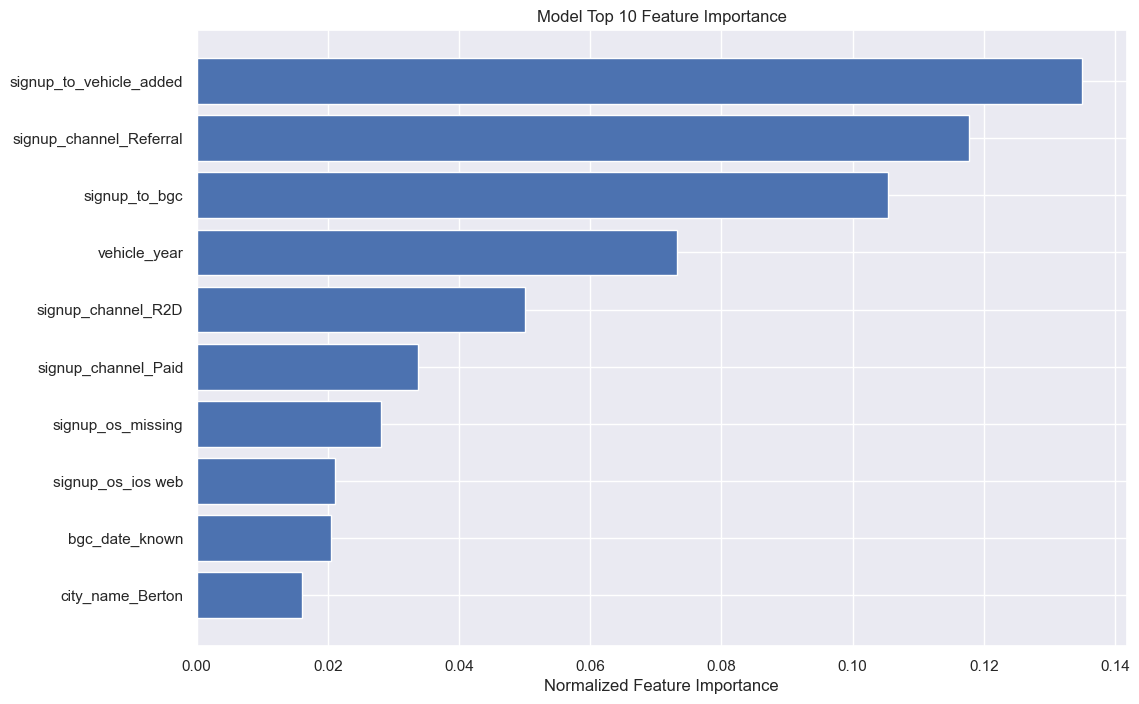

,index,feature,feature_importance,normalized_feature_importance
0,4,signup_to_vehicle_added,0.135016,0.135016
1,18,signup_channel_Referral,0.117742,0.117742
2,3,signup_to_bgc,0.105322,0.105322
3,0,vehicle_year,0.073177,0.073177
4,17,signup_channel_R2D,0.050053,0.050053
...,...,...,...,...
533,410,vehicle_model_Rendezvous,0.000000,0.000000
534,114,vehicle_model_Astro,0.000000,0.000000
535,294,vehicle_model_LHS,0.000000,0.000000
536,113,vehicle_model_Aspire,0.000000,0.000000


In [19]:
def plot_feature_importances(df):
    df = df.sort_values('feature_importance', ascending=False).reset_index()
    df['normalized_feature_importance'] = (
        df['feature_importance'] / df['feature_importance'].sum()
    )

    plt.figure(figsize=(12, 8))
    ax = plt.subplot()

    ax.barh(
        list(reversed(list(df.index[:10]))),
        df['normalized_feature_importance'].head(10),
        align='center'
    )

    ax.set_yticks(list(reversed(list(df.index[:10]))))
    ax.set_yticklabels(df['feature'].head(10))

    # Plot labeling
    plt.xlabel('Normalized Feature Importance')
    plt.title('Model Top 10 Feature Importance')
    plt.show()

    return df


plot_feature_importances(feature_importances_df)
